# **1. Perkenalan Dataset**

Dataset yang digunakan pada eksperimen ini adalah **Telco Customer Churn**.

- **Sumber Dataset**: Public repository (IBM Sample Data Sets / Kaggle *Telco Customer Churn*).
- **Konteks**: Sebuah perusahaan telekomunikasi ingin memprediksi pelanggan mana yang berpotensi berhenti berlangganan (*churn*). Kemampuan ini membantu tim retensi menyusun strategi agar pelanggan tetap loyal.
- **Jumlah data**: 7.043 baris dan 21 kolom.
- **Target**: kolom `Churn` (Yes = pelanggan berhenti, No = pelanggan bertahan) — sehingga ini merupakan permasalahan **klasifikasi biner**.
- **Fitur**: gabungan data demografi pelanggan (`gender`, `SeniorCitizen`, `Partner`, `Dependents`), layanan yang digunakan (`PhoneService`, `InternetService`, `OnlineSecurity`, dll.), serta informasi akun (`tenure`, `Contract`, `MonthlyCharges`, `TotalCharges`, `PaymentMethod`).

Dataset ini dipilih karena mengandung campuran fitur numerik dan kategorikal, memiliki *missing value* tersembunyi, serta target yang tidak seimbang — sehingga memerlukan tahapan EDA dan preprocessing yang menyeluruh.

# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh pustaka Python yang dibutuhkan untuk analisis data, visualisasi, serta preprocessing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
%matplotlib inline

print("Library berhasil diimpor.")

Library berhasil diimpor.


# **3. Memuat Dataset**

Dataset dimuat dari folder `telco_churn_raw` menggunakan `pandas`. Kita menampilkan beberapa baris awal untuk memastikan data terbaca dengan benar.

In [2]:
import os

# Path relatif terhadap folder notebook (preprocessing/)
RAW_PATH = os.path.join("..", "telco_churn_raw", "telco_churn_raw.csv")
if not os.path.exists(RAW_PATH):
    # fallback bila notebook dijalankan dari root repository
    RAW_PATH = os.path.join("telco_churn_raw", "telco_churn_raw.csv")

df = pd.read_csv(RAW_PATH)
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini kita menggali karakteristik dataset untuk memperoleh wawasan awal sebelum melakukan preprocessing dan pemodelan.

### 4.1 Informasi Struktur Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Perhatikan bahwa kolom `TotalCharges` terbaca sebagai `object` padahal seharusnya numerik. Ini indikasi adanya nilai non-numerik (spasi kosong) yang perlu ditangani pada tahap preprocessing.

### 4.2 Statistik Deskriptif

In [4]:
df.describe(include="number")

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### 4.3 Pengecekan Missing Value & Duplikat

In [6]:
print("Jumlah missing value per kolom:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "Tidak ada NaN eksplisit.")

# TotalCharges menyimpan missing value tersembunyi berupa string kosong
blank_total = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"\nJumlah TotalCharges kosong (spasi): {blank_total}")

print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

Jumlah missing value per kolom:
Tidak ada NaN eksplisit.

Jumlah TotalCharges kosong (spasi): 11

Jumlah baris duplikat: 0


### 4.4 Distribusi Target (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi (%):
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64


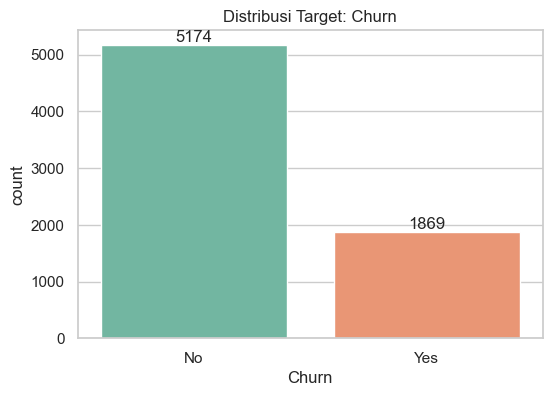

In [7]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print("\nProporsi (%):")
print((churn_counts / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Distribusi Target: Churn")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

Target `Churn` **tidak seimbang** (± 73% No vs 27% Yes). Ketidakseimbangan ini perlu diperhatikan saat evaluasi model (gunakan metrik selain akurasi seperti F1-score).

### 4.5 Distribusi Fitur Numerik

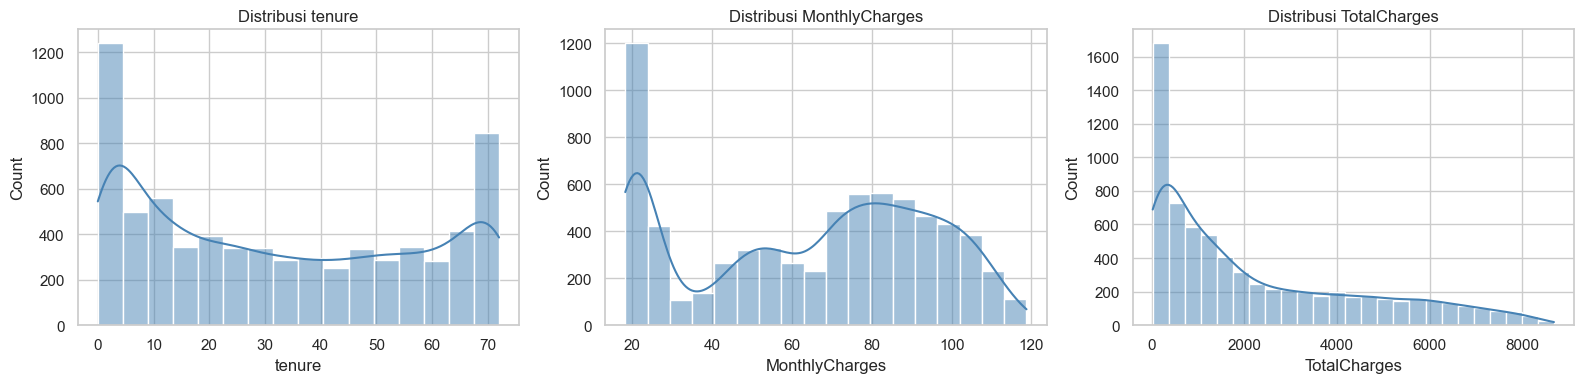

In [8]:
# Konversi sementara TotalCharges ke numerik hanya untuk keperluan visualisasi
tmp = df.copy()
tmp["TotalCharges"] = pd.to_numeric(tmp["TotalCharges"], errors="coerce")

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(tmp[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

### 4.6 Hubungan Fitur Kategorikal terhadap Churn

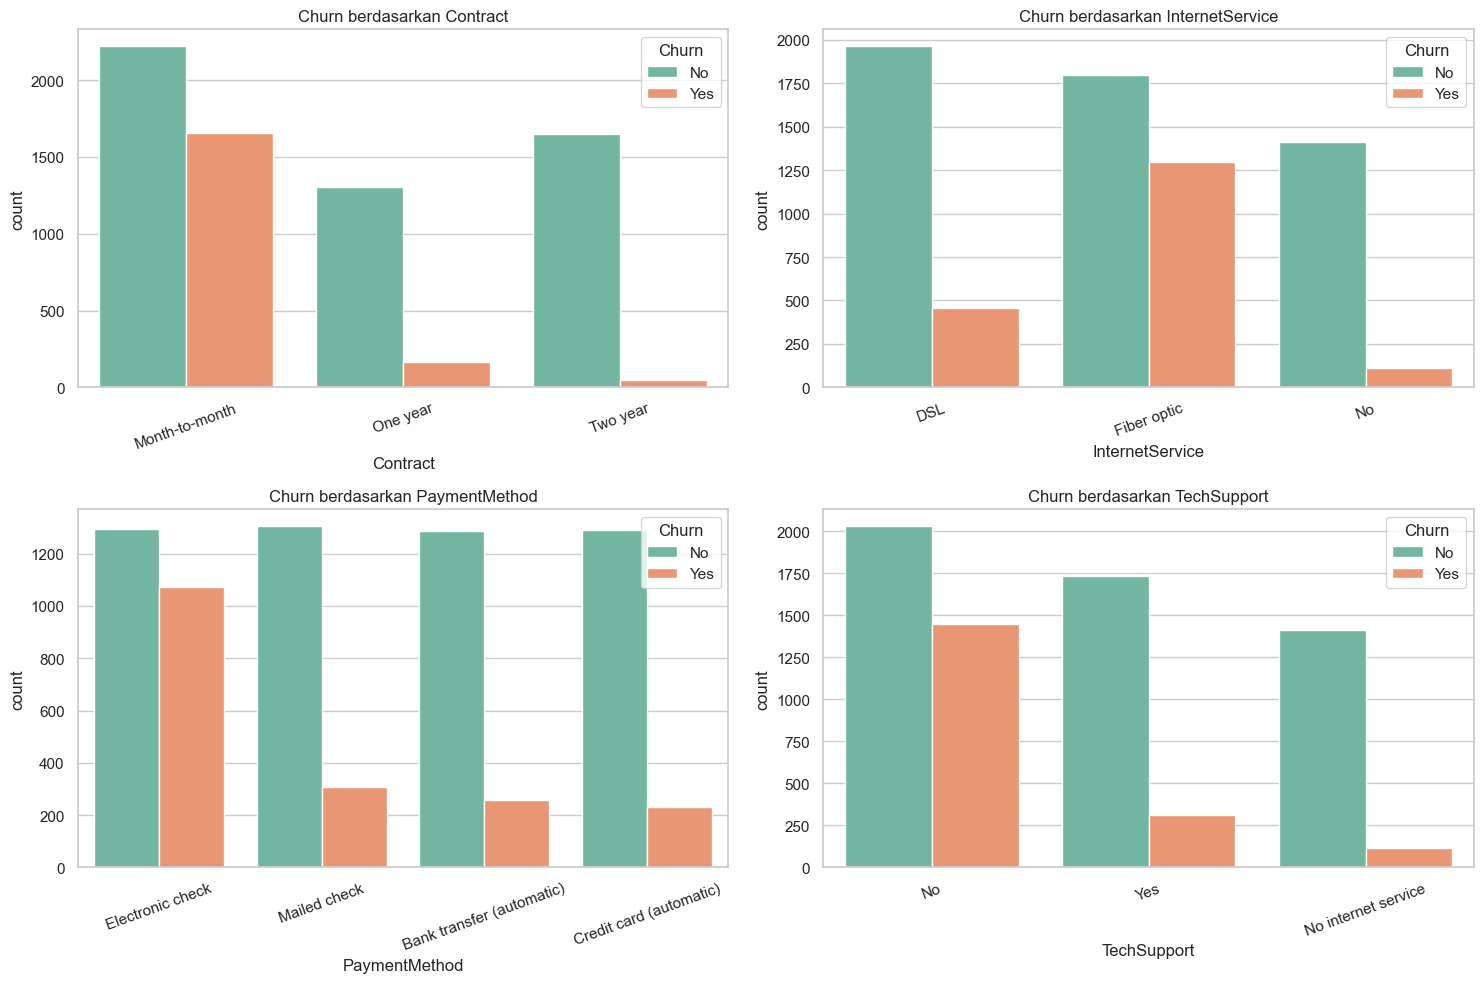

In [9]:
cat_plot = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.ravel(), cat_plot):
    sns.countplot(x=col, hue="Churn", data=df, ax=ax, palette="Set2")
    ax.set_title(f"Churn berdasarkan {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

Terlihat pola menarik: pelanggan dengan kontrak **Month-to-month**, layanan internet **Fiber optic**, dan tanpa **TechSupport** cenderung memiliki tingkat churn lebih tinggi.

### 4.7 Korelasi Antar Fitur Numerik

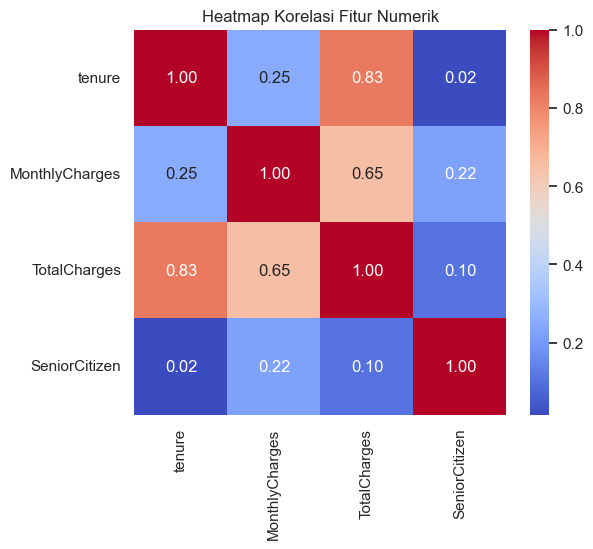

In [10]:
plt.figure(figsize=(6, 5))
corr = tmp[num_cols + ["SeniorCitizen"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

# **5. Data Preprocessing**

Berdasarkan hasil EDA, berikut tahapan preprocessing yang dilakukan:

1. **Menghapus kolom identifier** `customerID` (tidak informatif untuk pemodelan).
2. **Menangani missing value** pada `TotalCharges` — mengubah string kosong menjadi numerik lalu mengimputasi dengan 0 (baris tersebut memiliki `tenure` = 0, artinya pelanggan baru yang belum ditagih).
3. **Menghapus data duplikat**.
4. **Encoding target** `Churn`: Yes → 1, No → 0.
5. **Encoding fitur kategorikal biner** menjadi 0/1.
6. **One-Hot Encoding** untuk fitur kategorikal multi-kelas.
7. **Standardisasi** fitur numerik menggunakan `StandardScaler`.
8. **Membagi data** menjadi train/test untuk verifikasi.
9. **Menyimpan** dataset hasil preprocessing.

### 5.1 Menghapus Kolom Identifier

In [11]:
data = df.copy()
data = data.drop(columns=["customerID"])
print("Kolom setelah drop customerID:", data.shape[1])

Kolom setelah drop customerID: 20


### 5.2 Menangani Missing Value pada TotalCharges

In [12]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"].astype(str).str.strip(), errors="coerce")
print("Missing setelah konversi:", data["TotalCharges"].isna().sum())
# Baris kosong berkaitan dengan pelanggan baru (tenure = 0) -> imputasi 0
print("tenure pada baris TotalCharges kosong:", data.loc[data['TotalCharges'].isna(), 'tenure'].unique())
data["TotalCharges"] = data["TotalCharges"].fillna(0)
print("Missing setelah imputasi:", data["TotalCharges"].isna().sum())

Missing setelah konversi: 11
tenure pada baris TotalCharges kosong: [0]
Missing setelah imputasi: 0


### 5.3 Menghapus Data Duplikat

In [13]:
before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
print(f"Baris dihapus karena duplikat: {before - len(data)}")

Baris dihapus karena duplikat: 22


### 5.4 Encoding Target

In [14]:
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1}).astype(int)
data["Churn"].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

### 5.5 Encoding Fitur Kategorikal Biner

In [15]:
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])
data[binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


### 5.6 One-Hot Encoding Fitur Multi-kelas

In [16]:
multi_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod",
]
data = pd.get_dummies(data, columns=multi_cols, drop_first=True)
# Ubah kolom hasil one-hot (bool) menjadi integer 0/1
bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)
print("Jumlah kolom setelah encoding:", data.shape[1])
data.head()

Jumlah kolom setelah encoding: 31


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


### 5.7 Standardisasi Fitur Numerik

In [17]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
data[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7.021000e+03,7.021000e+03,7.021000e+03
mean,8.855219e-17,-2.105012e-16,-4.250505e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.323489e+00,-1.549942e+00,-1.008855e+00
25%,-9.566397e-01,-9.679060e-01,-8.309085e-01
50%,-1.414184e-01,1.845256e-01,-3.909726e-01
75%,9.183692e-01,8.330802e-01,6.683457e-01
max,1.611307e+00,1.792608e+00,2.822629e+00


### 5.8 Verifikasi dengan Train/Test Split

In [18]:
X = data.drop(columns=["Churn"])
y = data["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribusi target train:\n", y_train.value_counts(normalize=True).round(3))

X_train:

 (5616, 30) | X_test: (1405, 30)
Distribusi target train:
 Churn
0    0.736
1    0.264
Name: proportion, dtype: float64


### 5.9 Menyimpan Dataset Hasil Preprocessing

In [19]:
OUT_PATH = "telco_churn_preprocessing.csv"
data.to_csv(OUT_PATH, index=False)
print(f"Dataset hasil preprocessing tersimpan di: {OUT_PATH}")
print("Ukuran akhir:", data.shape)
data.head()

Dataset hasil preprocessing tersimpan di: telco_churn_preprocessing.csv
Ukuran akhir: (7021, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.282728,0,1,-1.164135,-0.995686,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.062387,1,0,-0.262811,-0.175262,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.241967,1,1,-0.365914,-0.961142,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.510759,0,0,-0.750058,-0.196769,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.241967,1,1,0.194503,-0.941951,1,...,0,0,0,0,0,0,0,0,1,0


---
## Kesimpulan

- Dataset **Telco Customer Churn** berhasil dimuat, dieksplorasi, dan diproses.
- Ditemukan 11 *missing value* tersembunyi pada `TotalCharges` yang telah ditangani, serta target yang tidak seimbang.
- Seluruh fitur kategorikal telah di-*encode* dan fitur numerik telah distandardisasi.
- Dataset akhir berisi **fitur numerik siap latih** dan disimpan sebagai `telco_churn_preprocessing.csv`.
- Langkah-langkah pada notebook ini selanjutnya dikonversi menjadi file otomatisasi `automate_Andi-Arif-Abdillah.py`.